# `torch.linalg.svd` CPU vs GPU benchmark

This notebook benchmarks `torch.linalg.svd(..., full_matrices=False)` on random tensors shaped like the key tensors used in this repo.

- The decomposition code operates on the last two dimensions `(T, D)`.
- In this codebase, `D` is typically the attention head dimension, often `128`.
- Batched benchmarks below mimic tensors shaped like `(batch, heads, tokens, head_dim)`.

The goal is to compare wall-clock runtime for CPU vs GPU on representative matrix sizes, not to validate numerical accuracy.

In [1]:
import math
import statistics
import time

import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

torch.manual_seed(0)

print(f'torch: {torch.__version__}')
print(f'cuda available: {torch.cuda.is_available()}')
print(f'cpu threads: {torch.get_num_threads()}')
if torch.cuda.is_available():
    print(f'gpu: {torch.cuda.get_device_name(0)}')


torch: 2.10.0+cpu
cuda available: False
cpu threads: 8


In [2]:
def sync_if_needed(device: torch.device) -> None:
    if device.type == 'cuda':
        torch.cuda.synchronize(device)


def benchmark_svd(
    shape,
    device,
    dtype=torch.float32,
    warmup=3,
    repeats=10,
):
    device = torch.device(device)
    x = torch.randn(shape, device=device, dtype=dtype)

    sync_if_needed(device)
    for _ in range(warmup):
        torch.linalg.svd(x, full_matrices=False)
    sync_if_needed(device)

    times_ms = []
    for _ in range(repeats):
        sync_if_needed(device)
        start = time.perf_counter()
        torch.linalg.svd(x, full_matrices=False)
        sync_if_needed(device)
        end = time.perf_counter()
        times_ms.append((end - start) * 1000.0)

    return {
        'mean_ms': statistics.mean(times_ms),
        'std_ms': statistics.stdev(times_ms) if len(times_ms) > 1 else 0.0,
        'min_ms': min(times_ms),
        'max_ms': max(times_ms),
    }


HEAD_DIM = 128
NUM_HEADS = 8
BATCH = 4
DTYPE = torch.float32
WARMUP = 3
REPEATS = 10

shape_specs = [
    {'label': 'single_16x128', 'shape': (16, HEAD_DIM)},
    {'label': 'single_32x128', 'shape': (32, HEAD_DIM)},
    {'label': 'single_64x128', 'shape': (64, HEAD_DIM)},
    {'label': 'single_128x128', 'shape': (128, HEAD_DIM)},
    {'label': 'heads_8x16x128', 'shape': (NUM_HEADS, 16, HEAD_DIM)},
    {'label': 'heads_8x32x128', 'shape': (NUM_HEADS, 32, HEAD_DIM)},
    {'label': 'heads_8x64x128', 'shape': (NUM_HEADS, 64, HEAD_DIM)},
    {'label': 'batch_4_heads_8x32x128', 'shape': (BATCH, NUM_HEADS, 32, HEAD_DIM)},
    {'label': 'batch_4_heads_8x64x128', 'shape': (BATCH, NUM_HEADS, 64, HEAD_DIM)},
    {'label': 'batch_1_heads_8x128x128', 'shape': (1, NUM_HEADS, 128, HEAD_DIM)},
]

shape_specs

[{'label': 'single_16x128', 'shape': (16, 128)},
 {'label': 'single_32x128', 'shape': (32, 128)},
 {'label': 'single_64x128', 'shape': (64, 128)},
 {'label': 'single_128x128', 'shape': (128, 128)},
 {'label': 'heads_8x16x128', 'shape': (8, 16, 128)},
 {'label': 'heads_8x32x128', 'shape': (8, 32, 128)},
 {'label': 'heads_8x64x128', 'shape': (8, 64, 128)},
 {'label': 'batch_4_heads_8x32x128', 'shape': (4, 8, 32, 128)},
 {'label': 'batch_4_heads_8x64x128', 'shape': (4, 8, 64, 128)},
 {'label': 'batch_1_heads_8x128x128', 'shape': (1, 8, 128, 128)}]

In [3]:
records = []

for spec in shape_specs:
    row = {
        'label': spec['label'],
        'shape': str(spec['shape']),
        'dtype': str(DTYPE).replace('torch.', ''),
    }

    cpu_stats = benchmark_svd(
        spec['shape'],
        device='cpu',
        dtype=DTYPE,
        warmup=WARMUP,
        repeats=REPEATS,
    )
    row.update({f'cpu_{k}': v for k, v in cpu_stats.items()})

    if torch.cuda.is_available():
        gpu_stats = benchmark_svd(
            spec['shape'],
            device='cuda',
            dtype=DTYPE,
            warmup=WARMUP,
            repeats=REPEATS,
        )
        row.update({f'gpu_{k}': v for k, v in gpu_stats.items()})
        row['gpu_speedup_vs_cpu'] = row['cpu_mean_ms'] / row['gpu_mean_ms']
    else:
        row['gpu_mean_ms'] = math.nan
        row['gpu_std_ms'] = math.nan
        row['gpu_min_ms'] = math.nan
        row['gpu_max_ms'] = math.nan
        row['gpu_speedup_vs_cpu'] = math.nan

    records.append(row)

df = pd.DataFrame(records)
display(df.round(3))


,label,shape,dtype,cpu_mean_ms,cpu_std_ms,cpu_min_ms,cpu_max_ms,gpu_mean_ms,gpu_std_ms,gpu_min_ms,gpu_max_ms,gpu_speedup_vs_cpu
0,single_16x128,"(16, 128)",float32,0.341,0.283,0.127,0.978,NaN,NaN,NaN,NaN,NaN
1,single_32x128,"(32, 128)",float32,0.617,0.423,0.325,1.700,NaN,NaN,NaN,NaN,NaN
2,single_64x128,"(64, 128)",float32,1.392,0.383,1.001,2.205,NaN,NaN,NaN,NaN,NaN
3,single_128x128,"(128, 128)",float32,1.949,0.318,1.487,2.525,NaN,NaN,NaN,NaN,NaN
4,heads_8x16x128,"(8, 16, 128)",float32,1.028,0.204,0.855,1.556,NaN,NaN,NaN,NaN,NaN
5,heads_8x32x128,"(8, 32, 128)",float32,2.353,0.469,1.889,3.475,NaN,NaN,NaN,NaN,NaN
6,heads_8x64x128,"(8, 64, 128)",float32,6.750,0.393,6.417,7.786,NaN,NaN,NaN,NaN,NaN
7,batch_4_heads_8x32x128,"(4, 8, 32, 128)",float32,11.123,1.315,8.947,13.502,NaN,NaN,NaN,NaN,NaN
8,batch_4_heads_8x64x128,"(4, 8, 64, 128)",float32,29.546,4.407,23.361,37.223,NaN,NaN,NaN,NaN,NaN
9,batch_1_heads_8x128x128,"(1, 8, 128, 128)",float32,15.006,1.904,12.370,17.745,NaN,NaN,NaN,NaN,NaN


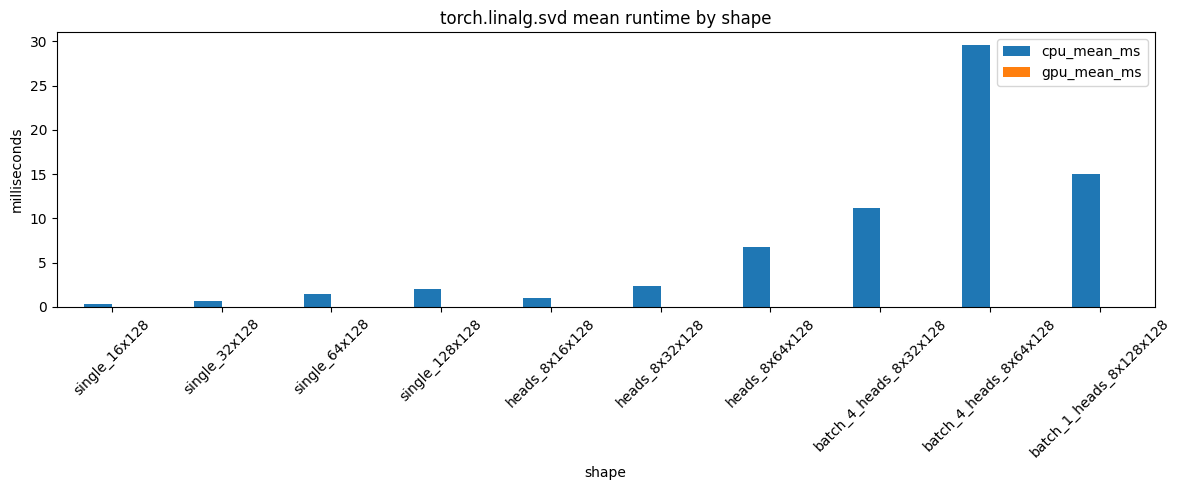

In [4]:
plot_df = df.copy()
plot_df['label'] = plot_df['label'].astype(str)

ax = plot_df.plot(
    x='label',
    y=['cpu_mean_ms', 'gpu_mean_ms'],
    kind='bar',
    figsize=(12, 5),
    rot=45,
    title='torch.linalg.svd mean runtime by shape',
)
ax.set_ylabel('milliseconds')
ax.set_xlabel('shape')
plt.tight_layout()
plt.show()

if torch.cuda.is_available():
    ax = plot_df.plot(
        x='label',
        y='gpu_speedup_vs_cpu',
        kind='bar',
        figsize=(12, 4),
        rot=45,
        legend=False,
        title='GPU speedup over CPU',
    )
    ax.set_ylabel('cpu_mean_ms / gpu_mean_ms')
    ax.set_xlabel('shape')
    plt.tight_layout()
    plt.show()


## Notes

- The benchmark uses random tensors and measures full SVD only.
- GPU timings include the actual CUDA kernel execution because the notebook synchronizes before and after each call.
- If you want more stable numbers, increase `REPEATS`.
- If you want to probe longer event windows, add more entries to `shape_specs`.
- If your target model uses a different head dimension, change `HEAD_DIM`.